## SANITY CHECK FOR RT-DETR
The purpose of this notebook is to try the rt-detr v2 model with a balanced 200-sample subset of our dataset to see if the model learns correctly (it does), observing the behaviour of the training loss.

**Configuration settings**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


!git clone https://github.com/angelo4o4/sixray-kd.git /content/sixray-kd
!bash /content/sixray-kd/scripts/setup_colab.sh subset.zip

import sys
sys.path.append('/content/sixray-kd')

**Imports and device check**

In [ ]:
import os
import json
import random
import numpy as np
import torch
import torchvision
from PIL import Image
from torch.utils.data import Subset
from transformers import AutoImageProcessor, AutoModelForObjectDetection
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from src.data.dataset import SixRayDataset, collate_fn

print(f"PyTorch version: {torch.__version__}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

PyTorch version: 2.10.0+cu128
Using device: cuda


In [ ]:
# Config
MODEL_NAME     = "PekingU/rtdetr_v2_r50vd"
EPOCHS         = 10
BATCH_SIZE     = 4
LR             = 1e-4
CHECKPOINT_DIR = "/content/drive/MyDrive/DatasetAPAI/SIXray_Project/checkpoints"

In [ ]:
# Paths
LOCAL_EXTRACT_PATH = "/content/data/subset"
CHECKPOINT_DIR     = "/content/drive/MyDrive/DatasetAPAI/SIXray_Project/checkpoints"
TRAIN_IMG_DIR      = os.path.join(LOCAL_EXTRACT_PATH, "train", "images")
TRAIN_JSON         = os.path.join(LOCAL_EXTRACT_PATH, "train.json")

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

**MODEL AND PROCESSOR LOADING**

In [ ]:
processor = AutoImageProcessor.from_pretrained(MODEL_NAME)
model = AutoModelForObjectDetection.from_pretrained(
    MODEL_NAME,
    ignore_mismatched_sizes=True,
)
model.to(device)
print("Model loaded to GPU")

**SETUP DATALOADER**

In [ ]:
try:
    train_dataset = SixRayDataset(
        image_dir=TRAIN_IMG_DIR,
        anno_file=TRAIN_JSON,
        processor=processor
    )

    # 200 images (100 pos/100 neg)
    positive_idx = []
    negative_idx = []

    for idx in range(len(train_dataset)):
      num_boxes = len(train_dataset.annotations[idx].get("annotations", []))
      if num_boxes > 0:
        positive_idx.append(idx)
      else:
        negative_idx.append(idx)
    print(f"Positive images found in the complete dataset: {len(positive_idx)}")
    print(f"Negative images found in the complete dataset: {len(negative_idx)}")

    NUM_SAMPLES = 100
    balanced_indices = negative_idx[:NUM_SAMPLES] + positive_idx[:NUM_SAMPLES]
    random.shuffle(balanced_indices)
    mini_dataset = Subset(train_dataset, balanced_indices)

    train_loader = DataLoader(
        mini_dataset,
        batch_size = 4,  # or 2
        shuffle=True,
        # num_workers=2,
        collate_fn=collate_fn
    )

    print(f"Dataset loaded correctly: {len(mini_dataset)} images.")

    # testing a batch
    batch = next(iter(train_loader))
    print(f"Shape Images (Batch): {batch['pixel_values'].shape}")
    print(f"Labels of first element: {batch['labels'][0]}")

except Exception as e:
    print(f"An error occurred: {e}")

Positive images found in the complete dataset: 7496
Negative images found in the complete dataset: 67464
Dataset loaded correctly: 200 images.
Shape Images (Batch): torch.Size([4, 3, 640, 640])
Labels of first element: {'size': tensor([640, 640]), 'image_id': tensor([12]), 'class_labels': tensor([0, 2, 3]), 'boxes': tensor([[0.4689, 0.6170, 0.1271, 0.1958],
        [0.6741, 0.2196, 0.0953, 0.3302],
        [0.2853, 0.6176, 0.2478, 0.3059]]), 'area': tensor([10192.0693, 12890.8125, 31046.5859]), 'iscrowd': tensor([0, 0, 0]), 'orig_size': tensor([785, 901])}


**VISUALIZATION**

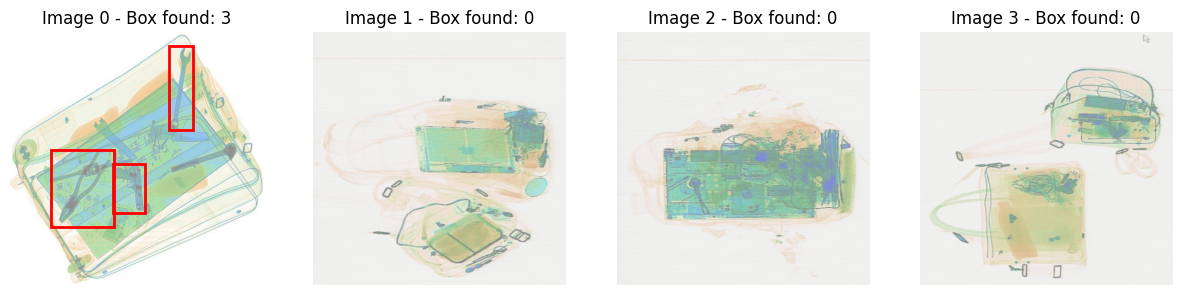

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def visualize_batch(batch, n_images=4):
    # Taking first elements of the batch
    images = batch["pixel_values"].cpu()
    labels = batch["labels"]

    fig, axs = plt.subplots(1, n_images, figsize=(15, 7))
    if n_images == 1: axs = [axs]

    for i in range(n_images):
        # Denormalization of the image
        img = images[i].permute(1, 2, 0).numpy()
        img = (img * 0.5) + 0.5
        img = np.clip(img, 0, 1)

        axs[i].imshow(img)

        # Drawing bounding boxes
        # RT-DETR uses natively format [cx, cy, w, h] normalized
        h, w, _ = img.shape
        for box in labels[i]["boxes"]:
            cx, cy, bw, bh = box.numpy()
            xmin = (cx - bw/2) * w
            ymin = (cy - bh/2) * h
            rect = patches.Rectangle(
                (xmin, ymin), bw * w, bh * h,
                linewidth=2, edgecolor='r', facecolor='none'
            )
            axs[i].add_patch(rect)

        axs[i].set_title(f"Image {i} - Box found: {len(labels[i]['boxes'])}")
        axs[i].axis('off')

    plt.show()

visualize_batch(batch)

**INSPECTING THE ALL THE BATCHES** (not needed)

In [ ]:
from ipywidgets import interact, IntSlider

# number of images per page
IMAGES_PER_PAGE = 10
TOTAL_PAGES = (len(mini_dataset) - 1) // IMAGES_PER_PAGE

def inspect_dataset(pagina):
    start_idx = pagina * IMAGES_PER_PAGE
    end_idx = min(start_idx + IMAGES_PER_PAGE, len(mini_dataset))

    # 2 x 5 grid
    fig, axs = plt.subplots(2, 5, figsize=(20, 8))
    axs = axs.flatten()

    for i, idx in enumerate(range(start_idx, end_idx)):
        item = mini_dataset[idx]
        img_tensor = item["pixel_values"]
        labels = item["labels"]

        img = img_tensor.permute(1, 2, 0).numpy()
        img = (img * 0.5) + 0.5
        img = np.clip(img, 0, 1)

        axs[i].imshow(img)

        h, w, _ = img.shape
        num_boxes = len(labels["boxes"])

        for box in labels["boxes"]:
            cx, cy, bw, bh = box.numpy()
            xmin = (cx - bw/2) * w
            ymin = (cy - bh/2) * h
            rect = patches.Rectangle(
                (xmin, ymin), bw * w, bh * h,
                linewidth=2, edgecolor='r', facecolor='none'
            )
            axs[i].add_patch(rect)

        # Images and boxes found
        axs[i].set_title(f"Image [{idx}]\nBox: {num_boxes}", fontsize=10)
        axs[i].axis('off')

    for j in range(i + 1, len(axs)):
        axs[j].axis('off')

    plt.tight_layout()
    plt.show()

# Interactive slider
print(f"Dataset total: {len(mini_dataset)} images.")
print(f"Available pages: da 0 a {TOTAL_PAGES}")
interact(inspect_dataset, pagina=IntSlider(min=0, max=TOTAL_PAGES, step=1, value=0, description="Page:"));

Dataset total: 200 images.
Available pages: da 0 a 19


interactive(children=(IntSlider(value=0, description='Page:', max=19), Output()), _dom_classes=('widget-interaâ€¦

## TRAINING

In the final training it should be added more parameters like dropout. For now, we can observe a reduction of the loss (from 42 to 23 in this first run), even if there is an high variance. It seems that the model is learning something (ok for this first sanity check notebook).

The loss is defined autmatically by the processor, it's the weighted sum of L1 loss (absolute errore on the box coordinates), GIoU Loss (error on overlapping of the area) and Focal Loss (basically classification loss).

In [ ]:
from transformers import get_cosine_schedule_with_warmup

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
# total steps for the LR scheduler
num_training_steps = len(train_loader) * EPOCHS
num_warmup_steps = int(0.1 * num_training_steps)
scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=num_training_steps
)

print(f"Stariting training for {EPOCHS} epochs")
print(f"Total steps: {num_training_steps} | Warmup step: {num_warmup_steps}")

model.train()

for epoch in range(EPOCHS):
    epoch_loss = 0
    print(f"\n--- Epoch {epoch + 1}/{EPOCHS} ---")

    for step, batch in enumerate(train_loader):
        pixel_values = batch["pixel_values"].to(device)
        labels = [{k: v.to(device) for k, v in t.items()} for t in batch["labels"]]

        outputs = model(pixel_values=pixel_values, labels=labels)
        loss = outputs.loss

        loss.backward()
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

        epoch_loss += loss.item()

        if step % 10 == 0:
            current_lr = scheduler.get_last_lr()[0]
            print(f"  Step {step}/{len(train_loader)} - Loss: {loss.item():.4f} - LR: {current_lr:.6f}")

    avg_loss = epoch_loss / len(train_loader)
    print(f"End of epoch {epoch + 1} - Average Loss: {avg_loss:.4f}")

    # Saving checkpoints on GDRIVE (not really needed for this simple run)
    save_path = os.path.join(CHECKPOINT_DIR, f"00_rtdetr_epoch_{epoch+1}.pth")
    torch.save(model.state_dict(), save_path)
    print(f"Checkpoint saved: {save_path}")

print("Training finished!")

Stariting training for 10 epochs
Total steps: 500 | Warmup step: 50

--- Epoch 1/10 ---
  Step 0/50 - Loss: 46.4464 - LR: 0.000002
  Step 10/50 - Loss: 25.5448 - LR: 0.000022
  Step 20/50 - Loss: 44.6347 - LR: 0.000042
  Step 30/50 - Loss: 42.3449 - LR: 0.000062
  Step 40/50 - Loss: 37.2248 - LR: 0.000082
End of epoch 1 - Average Loss: 42.0948
Checkpoint saved: /content/drive/MyDrive/DatasetAPAI/SIXray_Project/checkpoints/00_rtdetr_epoch_1.pth

--- Epoch 2/10 ---
  Step 0/50 - Loss: 38.7253 - LR: 0.000100
  Step 10/50 - Loss: 43.1100 - LR: 0.000100
  Step 20/50 - Loss: 40.8856 - LR: 0.000099
  Step 30/50 - Loss: 45.0637 - LR: 0.000099
  Step 40/50 - Loss: 33.5475 - LR: 0.000098
End of epoch 2 - Average Loss: 37.4050
Checkpoint saved: /content/drive/MyDrive/DatasetAPAI/SIXray_Project/checkpoints/00_rtdetr_epoch_2.pth

--- Epoch 3/10 ---
  Step 0/50 - Loss: 34.2514 - LR: 0.000097
  Step 10/50 - Loss: 43.8419 - LR: 0.000096
  Step 20/50 - Loss: 36.6986 - LR: 0.000094
  Step 30/50 - Loss: 